## 1

### <font color='#F5DEB3'>Задание №1

1. Для выполнения практикума рекомендуется использовать полносвязную нейронную сеть прямого распространения – MLPClassifier из библиотеки машинного обучения sklearn (см. описание алгоритма на странице библиотеки: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).
Допускается использовать другие библиотеки машинного обучения, если у Вас есть опыт работы с ними, однако, алгоритм должен остаться непременно тем, который задан в данном задании – полносвязная нейронная сеть прямого распространения.
Далее приведена инструкция из предположения использования библиотеки sklearn для реализации нейросетевого классификатора.

In [62]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yaml

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN

In [63]:
with open('C:/ML_Labs/LB3_ML_Yakushev/config/parameters.yaml', 'r', encoding='utf-8') as config_file:
    config = yaml.safe_load(config_file)

os.chdir(config['base']['root_project_dir'])

print(config)

{'base': {'random_state': 42, 'root_project_dir': 'C:/ML_Labs/LB3_ML_Yakushev'}, 'robot': {'dist_center': 0.125, 'wheel_angle': 30, 'wheel_radius': 0.04}, 'data': {'dataset_xlsx': 'data/Data_Set_(A+B).xlsx', 'dataset_test_xlsx': 'data/Data_Set_C.xlsx', 'target_column': 'Type', 'val_size': 0.2, 'type_space': 5}, 'MLP': {'model_params': {'cv_folds': 4}}}


In [64]:
V1 = pd.read_excel(config['data']['dataset_xlsx'])
display(V1.head(), V1.info(), V1.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      176 non-null    float64
 1   I2      176 non-null    float64
 2   I3      176 non-null    float64
 3   gx      176 non-null    float64
 4   gy      176 non-null    float64
 5   gz      176 non-null    float64
 6   ax      176 non-null    float64
 7   ay      176 non-null    float64
 8   az      176 non-null    float64
 9   V1real  176 non-null    float64
 10  V2real  176 non-null    float64
 11  V3real  176 non-null    float64
 12  N1      176 non-null    int64  
 13  N2      176 non-null    int64  
 14  N3      176 non-null    int64  
 15  Type    176 non-null    int64  
dtypes: float64(12), int64(4)
memory usage: 22.1 KB


,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
0,1.126697,0.021116,0.927601,0.712941,-0.252941,1.081765,0.043529,0.003174,0.011661,-249.352941,4.764706,265.235294,-5070,30,5239,1
1,1.039215,0.015083,0.953243,0.229412,0.276471,0.485294,0.013672,-0.005572,0.012164,-260.470588,0.000000,263.647059,-5320,-9,5391,1
2,0.911011,0.004525,0.947210,1.170588,0.222941,0.664118,0.011704,0.003720,0.005744,-268.411765,0.000000,268.411765,-4829,6,4786,1
3,0.692308,1.156862,0.550528,1.165294,0.698235,-3.421765,0.001321,-0.010311,-0.001522,141.352941,-306.529412,162.000000,2670,-5662,2875,1
4,0.529412,1.024133,0.453997,0.808235,0.090000,-1.449412,0.006218,-0.010986,-0.006247,155.647059,-314.470588,169.941176,2841,-5824,2967,1


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,0.489130,0.496730,0.515435,0.489197,-0.918759,21.789526,0.002805,-0.002898,-0.000539,165.642524,104.380920,341.394548,2816.715909,1649.357955,5811.000000,3.011364
std,0.308620,0.408217,0.299098,1.937254,1.837406,28.148416,0.017431,0.024498,0.022011,314.381930,358.226896,210.213155,5370.894465,6209.505848,3557.591498,1.426238
min,0.037607,0.000000,0.029060,-16.461250,-6.236250,-4.251176,-0.060758,-0.094824,-0.116547,-300.600000,-363.600000,-4.764706,-5519.000000,-8010.000000,-72.000000,1.000000
25%,0.273050,0.241026,0.296795,-0.052768,-1.613667,0.552147,-0.004743,-0.012504,-0.009770,-108.450000,-257.294118,168.023077,-1830.750000,-4892.000000,2914.500000,2.000000
50%,0.383629,0.383760,0.403419,0.488000,-0.189101,6.161208,0.002562,0.000008,0.000168,155.647059,57.375000,300.600000,2732.500000,1022.500000,4895.500000,3.000000
75%,0.696154,0.727800,0.780141,0.873414,0.276618,37.439714,0.012108,0.008070,0.009354,344.250000,339.621429,450.140625,5674.000000,5621.750000,7796.000000,4.000000
max,1.365008,1.561085,1.223229,9.905385,3.088000,87.827333,0.100601,0.100656,0.087982,772.200000,768.600000,786.600000,14770.000000,14829.000000,14554.000000,5.000000


In [65]:
dt = 0.01
# Метод Эйлера
V1_alpha = np.zeros(len(V1))
for i in range(1, len(V1)):
    V1_alpha[i] = V1_alpha[i-1] + V1['gz'].values[i-1] * dt

In [66]:
def compute_V2_V3(V1, V1_alpha, config):
    l = config['robot']['dist_center']
    r = config['robot']['wheel_radius']
    theta_degree = config['robot']['wheel_angle']

    theta = np.radians(theta_degree)         # угол установки колёс
    alpha = V1_alpha 
    n = len(alpha)                  # массив углов поворота робота

    # Знаки скоростей вращения для коррекции знаков токов
    omega_arr = V1[['V1real', 'V2real', 'V3real']].values
    sign_omega = np.sign(omega_arr)


    # Создаём массивы для матриц (n,3,3)
    M_vel = np.zeros((n, 3, 3))
    M_curr = np.zeros((n, 3, 3))

    # ----- Матрица скоростей -----
    M_vel[:,0,0] = - (2/3) * np.cos(alpha - theta)
    M_vel[:,0,1] =   (2/3) * np.sin(alpha)
    M_vel[:,0,2] =   (2/3) * np.cos(alpha + theta)
    
    M_vel[:,1,0] = - (2/3) * np.sin(alpha - theta)
    M_vel[:,1,1] = - (2/3) * np.cos(alpha)
    M_vel[:,1,2] =   (2/3) * np.sin(alpha + theta)
    
    M_vel[:,2,0] = 1/(3*l)
    M_vel[:,2,1] = 1/(3*l)
    M_vel[:,2,2] = 1/(3*l)

    M_curr[:,0,:] = M_vel[:,0,:]
    M_curr[:,1,:] = M_vel[:,1,:]
    M_curr[:,2,0] = 1/3
    M_curr[:,2,1] = 1/3
    M_curr[:,2,2] = 1/3


    # ----- Вычисление Vx, Vy, Ω -----
    V = np.einsum('ijk,ik->ij', M_vel, omega_arr) * r   # (n,3)

    # ----- Вычисление Ix, Iy, Iφ -----
    I_arr = V1[['I1', 'I2', 'I3']].values
    I_signed = I_arr * sign_omega
    I_vec = np.einsum('ijk,ik->ij', M_curr, I_signed)   # (n,3)

    # ----- IΣ (суммарная трудоёмкость) -----
    I_sum = np.sum(np.abs(I_vec), axis=1)

    # ----- Вычисление V3 (относительные параметры) -----
    eps = 1e-9
    Tx = V[:,0] / (I_vec[:,0] + eps)
    Ty = V[:,1] / (I_vec[:,1] + eps)
    Tphi = V[:,2] / (I_vec[:,2] + eps)
    Tz = V1['gz'].values / (I_vec[:,2] + eps)

    # Формируем DataFrame V2
    V2 = pd.DataFrame({
        'Vx': V[:,0],
        'Vy': V[:,1],
        'Ω': V[:,2],
        'Ix': I_vec[:,0],
        'Iy': I_vec[:,1],
        'Iφ': I_vec[:,2],
        'IΣ': I_sum
    }, index=V1.index)

    # Формируем DataFrame V3
    V3 = pd.DataFrame({
        'Tx': Tx,
        'Ty': Ty,
        'Tφ': Tphi,
        'Tz': Tz
    }, index=V1.index)

    return V2, V3

In [67]:
V2, V3 = compute_V2_V3(V1, V1_alpha, config)
display(V2, V3)

,Vx,Vy,Ω,Ix,Iy,Iφ,IΣ
0,11.883906,0.084706,2.202353,1.186050,-0.080443,-0.059327,1.325819
1,12.102812,0.173284,0.338824,1.150589,-0.016212,-0.028657,1.195458
2,12.395886,0.194267,0.000000,1.072523,0.028876,0.012066,1.113466
3,0.204104,12.226420,-0.338824,-0.108285,1.183399,0.028658,1.320342
4,0.481608,12.722227,1.185882,-0.031506,1.011005,-0.013575,1.056087
...,...,...,...,...,...,...,...
171,0.028497,-0.414714,111.744000,-0.054286,0.100141,0.336182,0.490609
172,0.062450,-0.387902,112.128000,-0.010527,-0.011989,0.329345,0.351860
173,0.176185,0.260828,237.696000,-0.037249,-0.053799,0.352137,0.443184
174,0.073458,-0.306065,237.504000,-0.051267,-0.012751,0.378347,0.442366


,Tx,Ty,Tφ,Tz
0,10.019739,-1.052996,-37.122516,-18.234057
1,10.518799,-10.688682,-11.823235,-16.934321
2,11.557684,6.727548,0.000000,55.038711
3,-1.884873,10.331615,-11.823016,-119.400142
4,-15.286012,12.583739,-87.358201,106.771135
...,...,...,...,...
171,-0.524940,-4.141298,332.391204,119.399547
172,-5.932590,32.354749,340.458077,113.635818
173,-4.729969,-4.848186,675.010681,235.599826
174,-1.432854,24.002753,627.740458,220.129233


In [68]:
V13 = pd.concat([V1, V3], axis=1)
display(V13)

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type,Tx,Ty,Tφ,Tz
0,1.126697,0.021116,0.927601,0.712941,-0.252941,1.081765,0.043529,0.003174,0.011661,-249.352941,4.764706,265.235294,-5070,30,5239,1,10.019739,-1.052996,-37.122516,-18.234057
1,1.039215,0.015083,0.953243,0.229412,0.276471,0.485294,0.013672,-0.005572,0.012164,-260.470588,0.000000,263.647059,-5320,-9,5391,1,10.518799,-10.688682,-11.823235,-16.934321
2,0.911011,0.004525,0.947210,1.170588,0.222941,0.664118,0.011704,0.003720,0.005744,-268.411765,0.000000,268.411765,-4829,6,4786,1,11.557684,6.727548,0.000000,55.038711
3,0.692308,1.156862,0.550528,1.165294,0.698235,-3.421765,0.001321,-0.010311,-0.001522,141.352941,-306.529412,162.000000,2670,-5662,2875,1,-1.884873,10.331615,-11.823016,-119.400142
4,0.529412,1.024133,0.453997,0.808235,0.090000,-1.449412,0.006218,-0.010986,-0.006247,155.647059,-314.470588,169.941176,2841,-5824,2967,1,-15.286012,12.583739,-87.358201,106.771135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,0.288889,0.449573,0.270085,0.153333,-2.288667,40.140000,-0.019906,0.003939,-0.000586,349.200000,340.200000,358.200000,5847,5663,5901,5,-0.524940,-4.141298,332.391204,119.399547
172,0.314530,0.331624,0.341880,0.096000,-2.154667,37.425333,-0.015479,0.000993,-0.009017,347.400000,343.800000,360.000000,6025,6018,6005,5,-5.932590,32.354749,340.458077,113.635818
173,0.287179,0.377778,0.391453,-1.820667,-5.030000,82.963333,0.027490,0.046403,-0.012874,750.600000,739.800000,738.000000,12100,12073,12049,5,-4.729969,-4.848186,675.010681,235.599826
174,0.370940,0.427350,0.336752,-0.624000,-4.574000,83.285333,0.014160,-0.043896,0.003906,734.400000,745.200000,747.000000,12493,12493,12564,5,-1.432854,24.002753,627.740458,220.129233


In [69]:
type_space = config['data']['type_space']
target_col = [config['data']['target_column']]
feature_cols = [col for col in V13.columns if col not in target_col]

data_x = np.array(V13.drop(target_col, axis=1))
data_y = np.array(V13[target_col]).ravel()

data_y = np.where(data_y == type_space, 1, 0)

### <font color='#F5DEB3'>Задание №2

Провести небольшую предварительную серию экспериментов с параметрами “hidden_layer_sizes”, “activation”, “solver” и “max_iter”, **добиваясь наиболее близких между собой значений критерия кросс-валидации (перекрестного критерия ошибки) на обучающей выборке (Data Set_Train)** для того, чтобы избежать переобучения сети и правильно подобрать параметры алгоритма. При этом сами значения кросс-валидации должны быть не только устойчивыми (близкими к друг другу), но и быть как можно меньше (т.к. представляют собой значения ошибок на тестовых подвыборках).

### <font color='#F5DEB3'>Задание №3

**Необходимо добиться** в режиме работы «на результат» как можно более высокой точности прогнозирования выходной величины (по критерию F1, а также по устойчивости кросс-валидации) в зависимости от следующих параметров.

In [70]:
# ------------------- Параметры перебора -------------------
hidden_options = [(3,2), (10,2), (3,3), (10,3), (3,5), (10,5)]
act_options = ['relu', 'tanh', 'logistic']
solv_options = ['adam']
max_iter_options = [5000, 10000]

random_state = config['base']['random_state']
cv_folds = config['MLP']['model_params']['cv_folds']

# ------------------- Сбор результатов -------------------
results = []
combo_id = 0

for hls in hidden_options:
    for act in act_options:
        for solv in solv_options:
            for max_it in max_iter_options:
                combo_id += 1
                mlp = MLPClassifier(
                    hidden_layer_sizes=hls,
                    activation=act,
                    solver=solv,
                    max_iter=max_it,
                    random_state=random_state,
                )
                
                # Кросс-валидация для Accuracy
                scores_acc = cross_val_score(mlp, data_x, data_y, cv=cv_folds, scoring='accuracy')
                mean_acc = scores_acc.mean()
                std_acc  = scores_acc.std()
                
                # Кросс-валидация для F1-score
                scores_f1 = cross_val_score(mlp, data_x, data_y, cv=cv_folds, scoring='f1')
                mean_f1 = scores_f1.mean()
                std_f1  = scores_f1.std()
                
                # Сохраняем в список
                results.append({
                    'combo_id': combo_id,
                    'hidden_layer_sizes': str(hls),
                    'activation': act,
                    'solver': solv,
                    'max_iter': max_it,
                    'cv_mean_accuracy': mean_acc,
                    'cv_std_accuracy': std_acc,
                    'cv_mean_f1': mean_f1,
                    'cv_std_f1': std_f1
                })

# ------------------- DataFrame с результатами -------------------
df_results = pd.DataFrame(results)

# Сохранение в файл
df_results.to_csv('hyperparameter_tuning_results.csv', index=False, encoding='utf-8')

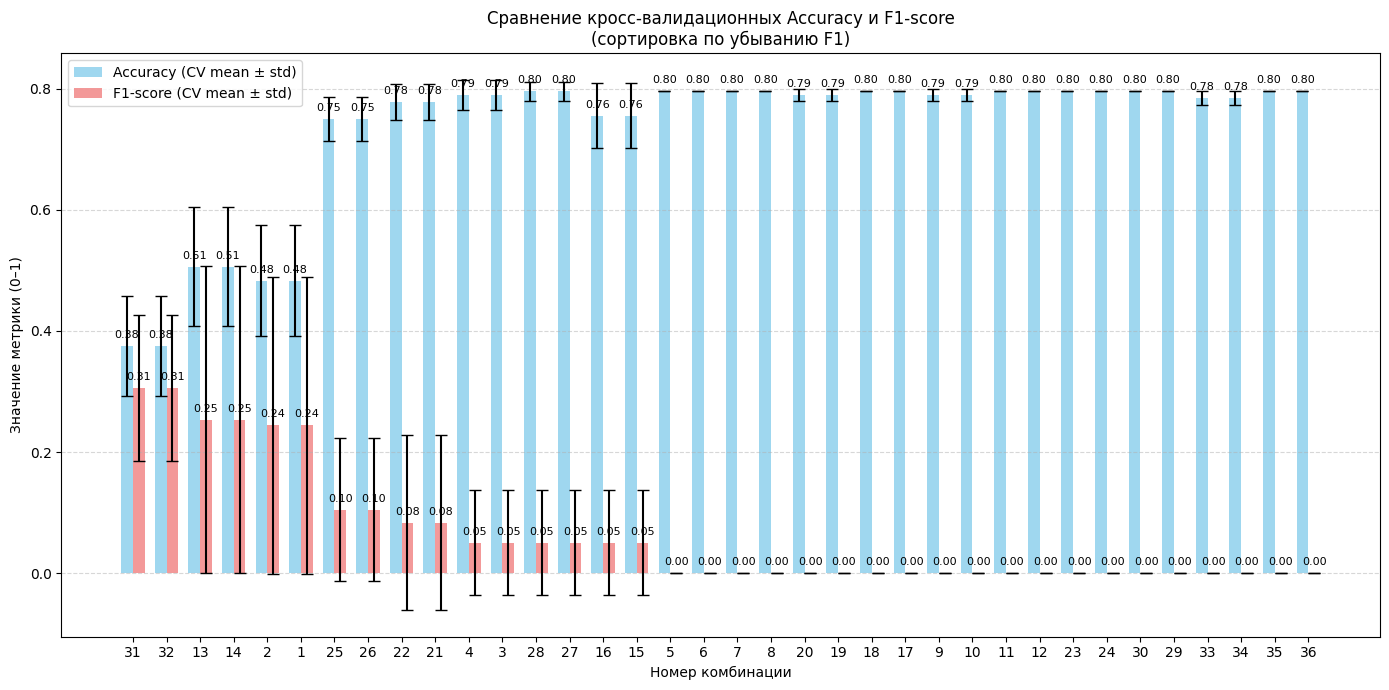

In [71]:
df_results['cv_mean_accuracy_frac'] = df_results['cv_mean_accuracy']  # уже в долях
df_results['cv_std_accuracy_frac'] = df_results['cv_std_accuracy']

# Сортируем по убыванию F1 (наиболее важная метрика)
df_sorted = df_results.sort_values('cv_mean_f1', ascending=False).reset_index(drop=True)

# Позиции для столбцов
x = np.arange(len(df_sorted))
width = 0.35  # ширина одного столбца

fig, ax = plt.subplots(figsize=(14, 7))

# Столбцы для Accuracy
bars_acc = ax.bar(x - width/2, df_sorted['cv_mean_accuracy_frac'], width,
                  yerr=df_sorted['cv_std_accuracy_frac'], capsize=4,
                  label='Accuracy (CV mean ± std)', color='skyblue', alpha=0.8)

# Столбцы для F1-score
bars_f1 = ax.bar(x + width/2, df_sorted['cv_mean_f1'], width,
                 yerr=df_sorted['cv_std_f1'], capsize=4,
                 label='F1-score (CV mean ± std)', color='lightcoral', alpha=0.8)

# Подписи оси X: номера комбинаций (можно добавить краткие гиперпараметры, но это перегрузит)
ax.set_xlabel('Номер комбинации')
ax.set_ylabel('Значение метрики (0–1)')
ax.set_title('Сравнение кросс-валидационных Accuracy и F1-score\n(сортировка по убыванию F1)')
ax.set_xticks(x)
ax.set_xticklabels(df_sorted['combo_id'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Добавим числовые значения поверх столбцов (опционально)
for bar in bars_acc:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars_f1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('hyperparameter_tuning_histograms.png', dpi=600)
plt.show()

In [72]:
import ast

def plot_model_by_combo_id(combo_id, df_results, data_x, data_y, random_state):
    """
    Обучает MLPClassifier с гиперпараметрами, соответствующими combo_id,
    выводит информацию о модели и строит график реальных и предсказанных классов.
    """
    # 1. Поиск комбинации в таблице результатов
    selected_row = df_results[df_results['combo_id'] == combo_id]
    if selected_row.empty:
        print(f"Ошибка: комбинация с номером {combo_id} не найдена!")
        return
    row = selected_row.iloc[0]

    # 2. Извлечение гиперпараметров
    hls = ast.literal_eval(row['hidden_layer_sizes'])
    act = row['activation']
    solv = row['solver']
    max_it = row['max_iter']

    # 3. Вывод информации (в требуемом формате)
    print(f"Номер выборки - {combo_id}")
    print(f"Гиперпараметры - hidden_layer_sizes={hls}, activation='{act}', solver='{solv}', max_iter={max_it}")
    print(f"Accuracy = {row['cv_mean_accuracy']:.4f} ± {row['cv_std_accuracy']:.4f}, "
          f"F1-score = {row['cv_mean_f1']:.4f} ± {row['cv_std_f1']:.4f}")

    # 4. Создание и обучение модели
    mlp = MLPClassifier(
        hidden_layer_sizes=hls,
        activation=act,
        solver=solv,
        max_iter=max_it,
        random_state=random_state,
    )
    mlp.fit(data_x, data_y)

    # 5. Предсказание на обучающих данных
    y_pred_class = mlp.predict(data_x)

    # 6. Визуализация (первые n_show примеров)
    n_show = min(1000, len(data_y))
    indices = np.arange(n_show)

    plt.figure(figsize=(14, 6))
    plt.plot(indices, data_y[:n_show], label='Реальные метки (0/1)',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred_class[:n_show], label='Предсказанный класс (0/1)',
             color='red', linewidth=2, alpha=0.8)
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс (0 или 1)')
    plt.title(f'Сравнение реальных и предсказанных классов (комбинация №{combo_id}, первые {n_show} примеров)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('best_model.png', dpi=600)
    plt.show()

Номер выборки - 15
Гиперпараметры - hidden_layer_sizes=(3, 3), activation='tanh', solver='adam', max_iter=5000
Accuracy = 0.7557 ± 0.0542, F1-score = 0.0500 ± 0.0866


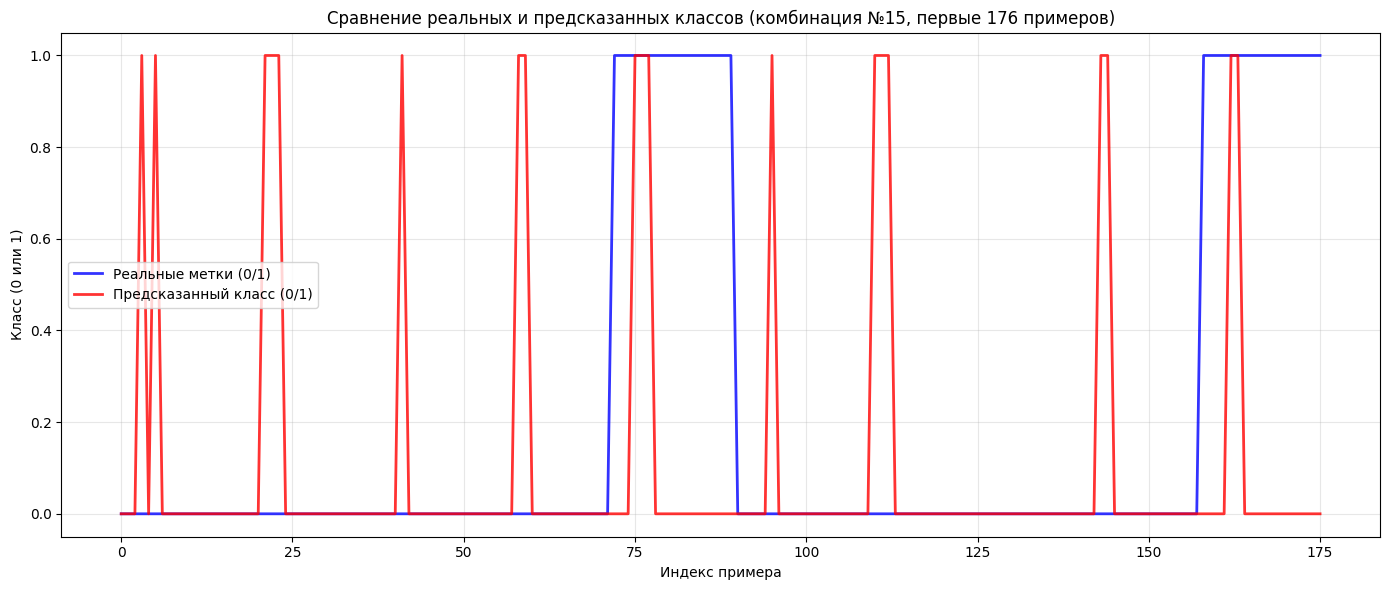

In [73]:
number_param = 15
plot_model_by_combo_id(number_param, df_results, data_x, data_y, random_state)

### <font color='#F5DEB3'>Задание №4

Зафиксировать **лучший полученный результат** по п.3 – выставить в блокноте результат лучшего найденного результата обучения (график и значения критериев понадобятся для отчёта).

In [74]:
type_space = config['data']['type_space']
target_col = [config['data']['target_column']]
feature_cols = [col for col in V13.columns if col not in target_col]

data_x = np.array(V13.drop(target_col, axis=1))
data_y = np.array(V13[target_col]).ravel()

data_y = np.where(data_y == type_space, 1, 0)

scaler = MinMaxScaler()
data_x_scaled = scaler.fit_transform(data_x)

In [75]:
# ------------------- Параметры перебора -------------------
hidden_options = [(3,2), (10,2), (3,3), (10,3), (3,5), (10,5)]
act_options = ['relu', 'tanh', 'logistic']
solv_options = ['adam']
max_iter_options = [5000, 10000]

random_state = config['base']['random_state']
cv_folds = config['MLP']['model_params']['cv_folds']

# ------------------- Сбор результатов -------------------
results = []
combo_id = 0

for hls in hidden_options:
    for act in act_options:
        for solv in solv_options:
            for max_it in max_iter_options:
                combo_id += 1
                mlp = MLPClassifier(
                    hidden_layer_sizes=hls,
                    activation=act,
                    solver=solv,
                    max_iter=max_it,
                    random_state=random_state,
                )
                
                # Кросс-валидация для Accuracy
                scores_acc = cross_val_score(mlp, data_x_scaled, data_y, cv=cv_folds, scoring='accuracy')
                mean_acc = scores_acc.mean()
                std_acc  = scores_acc.std()
                
                # Кросс-валидация для F1-score
                scores_f1 = cross_val_score(mlp, data_x_scaled, data_y, cv=cv_folds, scoring='f1')
                mean_f1 = scores_f1.mean()
                std_f1  = scores_f1.std()
                
                # Сохраняем в список
                results.append({
                    'combo_id': combo_id,
                    'hidden_layer_sizes': str(hls),
                    'activation': act,
                    'solver': solv,
                    'max_iter': max_it,
                    'cv_mean_accuracy': mean_acc,
                    'cv_std_accuracy': std_acc,
                    'cv_mean_f1': mean_f1,
                    'cv_std_f1': std_f1
                })

# ------------------- DataFrame с результатами -------------------
df_results_norm = pd.DataFrame(results)

# Сохранение в файл
df_results_norm.to_csv('hyperparameter_tuning_results_norm.csv', index=False, encoding='utf-8')

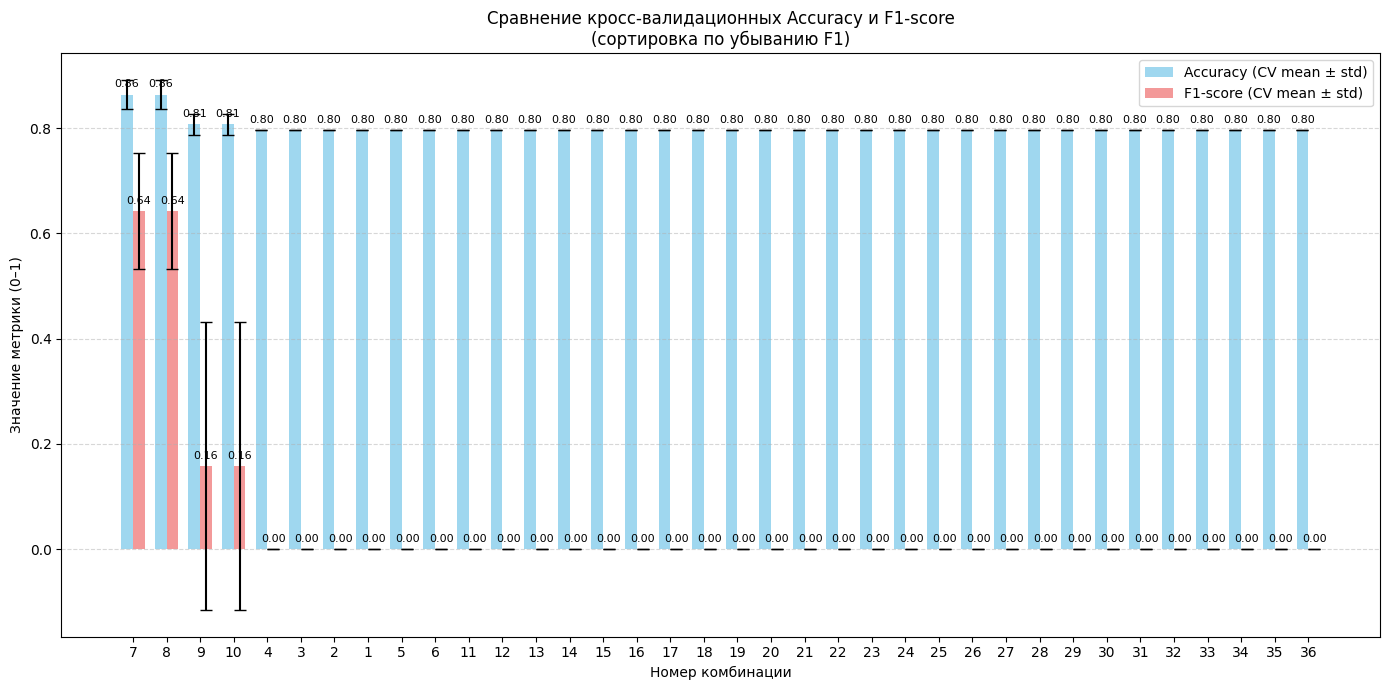

In [76]:
df_results_norm['cv_mean_accuracy_frac'] = df_results_norm['cv_mean_accuracy']  # уже в долях
df_results_norm['cv_std_accuracy_frac'] = df_results_norm['cv_std_accuracy']

# Сортируем по убыванию F1 (наиболее важная метрика)
df_sorted = df_results_norm.sort_values('cv_mean_f1', ascending=False).reset_index(drop=True)

# Позиции для столбцов
x = np.arange(len(df_sorted))
width = 0.35  # ширина одного столбца

fig, ax = plt.subplots(figsize=(14, 7))

# Столбцы для Accuracy
bars_acc = ax.bar(x - width/2, df_sorted['cv_mean_accuracy_frac'], width,
                  yerr=df_sorted['cv_std_accuracy_frac'], capsize=4,
                  label='Accuracy (CV mean ± std)', color='skyblue', alpha=0.8)

# Столбцы для F1-score
bars_f1 = ax.bar(x + width/2, df_sorted['cv_mean_f1'], width,
                 yerr=df_sorted['cv_std_f1'], capsize=4,
                 label='F1-score (CV mean ± std)', color='lightcoral', alpha=0.8)

# Подписи оси X: номера комбинаций (можно добавить краткие гиперпараметры, но это перегрузит)
ax.set_xlabel('Номер комбинации')
ax.set_ylabel('Значение метрики (0–1)')
ax.set_title('Сравнение кросс-валидационных Accuracy и F1-score\n(сортировка по убыванию F1)')
ax.set_xticks(x)
ax.set_xticklabels(df_sorted['combo_id'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Добавим числовые значения поверх столбцов (опционально)
for bar in bars_acc:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars_f1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('hyperparameter_tuning_histograms_norm.png', dpi=600)
plt.show()

Номер выборки - 7
Гиперпараметры - hidden_layer_sizes=(10, 2), activation='relu', solver='adam', max_iter=5000
Accuracy = 0.8636 ± 0.0278, F1-score = 0.6425 ± 0.1101


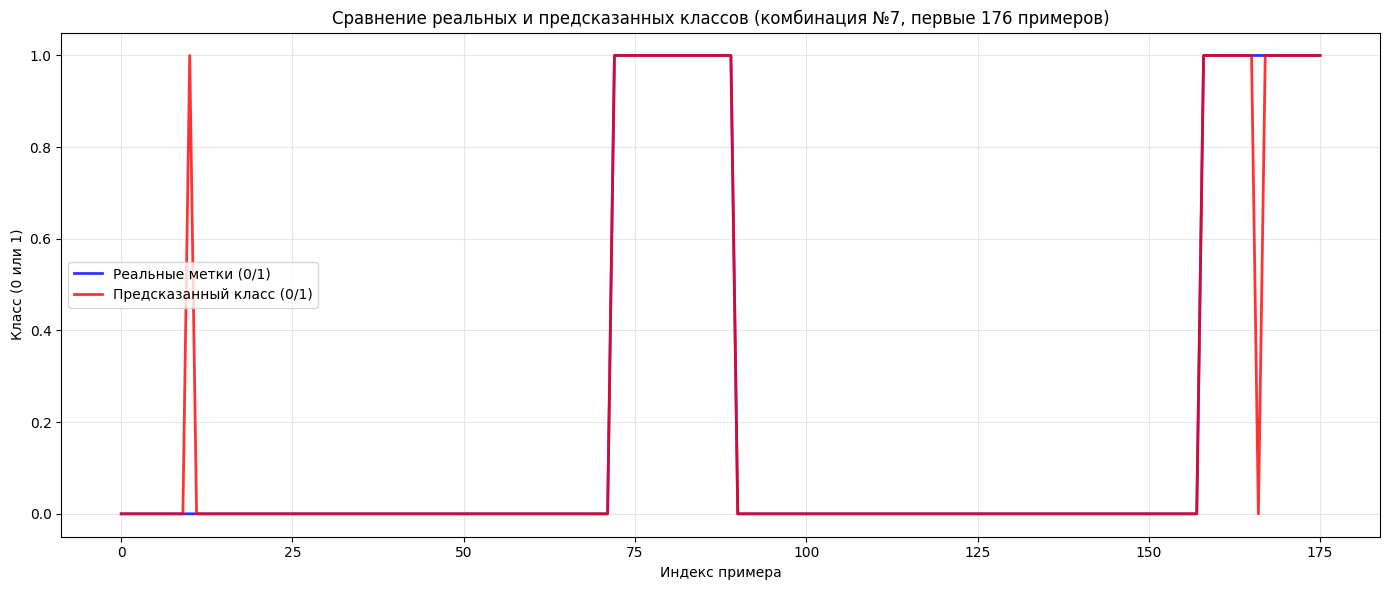

In [77]:
number_param = 7
plot_model_by_combo_id(number_param, df_results_norm, data_x_scaled, data_y, random_state)

In [78]:
smote = SMOTE(random_state=42)
adasyn = ADASYN(random_state=42)

X_smote, Y_smote = smote.fit_resample(data_x_scaled, data_y)
X_adasyn, Y_adasyn = adasyn.fit_resample(data_x_scaled, data_y)


In [79]:
best_params = {
    'hidden_layer_sizes': (10, 2),
    'activation': 'relu',
    'solver': 'adam',
    'max_iter': 5000,
    'random_state': 42,
}

In [80]:
def plot_predictions(model, X, y_true, n_show=1000, title_suffix='', save_path='predictions_plot.png'):
    """
    Строит график сравнения реальных и предсказанных классов для обученной модели.

    Параметры:
    ----------
    model : обученный классификатор с методом predict
    X : np.ndarray, матрица признаков
    y_true : np.ndarray, вектор истинных меток (0/1)
    n_show : int, количество отображаемых примеров (первые n_show)
    title_suffix : str, дополнительный текст в заголовке
    save_path : str, путь для сохранения графика
    """
    y_pred = model.predict(X)
    
    n = min(n_show, len(y_true))
    indices = np.arange(n)
    
    plt.figure(figsize=(14, 6))
    plt.plot(indices, y_true[:n], label='Реальные метки',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred[:n], label='Предсказанные классы',
             color='red', linewidth=2, alpha=0.8)
    
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс (0/1)')
    title = 'Сравнение реальных и предсказанных классов'
    if title_suffix:
        title += f' ({title_suffix})'
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=600)
    plt.show()

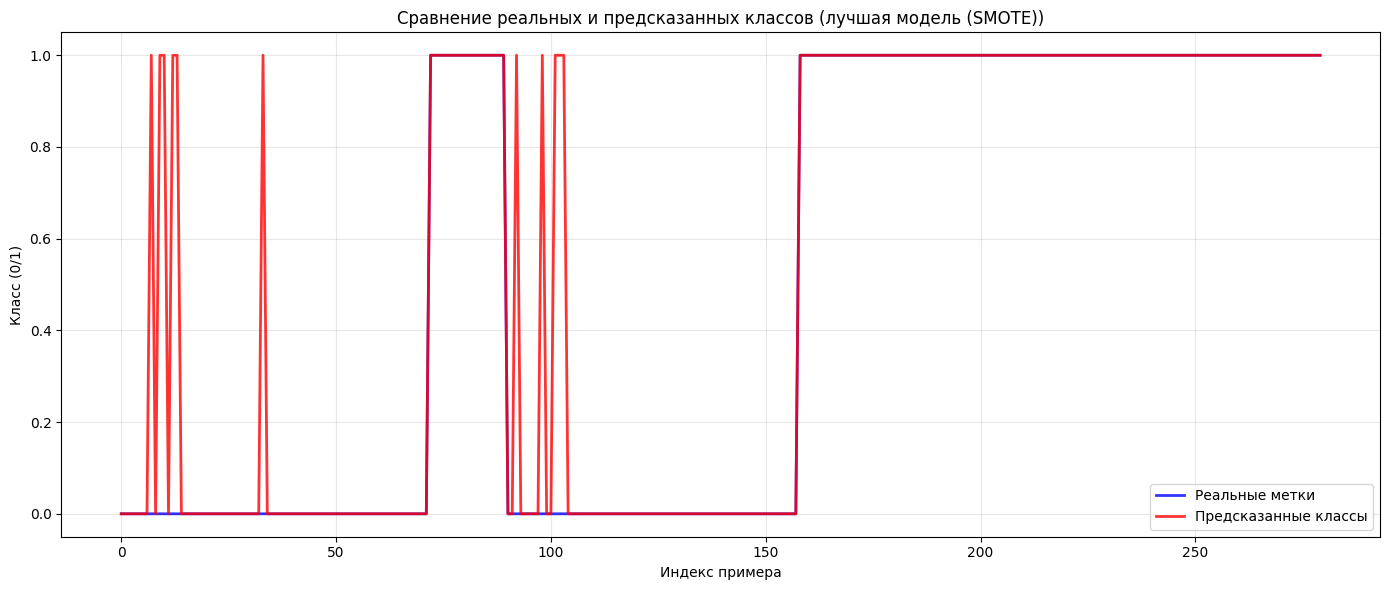

In [81]:
mlp = MLPClassifier(**best_params)
                
# Кросс-валидация для Accuracy
scores_acc = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='accuracy')
mean_acc = scores_acc.mean()
std_acc  = scores_acc.std()

# Кросс-валидация для F1-score
scores_f1 = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='f1')
mean_f1 = scores_f1.mean()
std_f1  = scores_f1.std()

# Сохраняем в список
results.append({
    'hidden_layer_sizes': str(hls),
    'activation': act,
    'solver': solv,
    'max_iter': max_it,
    'cv_mean_accuracy': mean_acc,
    'cv_std_accuracy': std_acc,
    'cv_mean_f1': mean_f1,
    'cv_std_f1': std_f1
})

df_results_smote = pd.DataFrame(results)

mlp.fit(X_smote, Y_smote)

plot_predictions(mlp, X_smote, Y_smote, 
                 title_suffix='лучшая модель (SMOTE)', 
                 save_path='best_model_predictions.png')


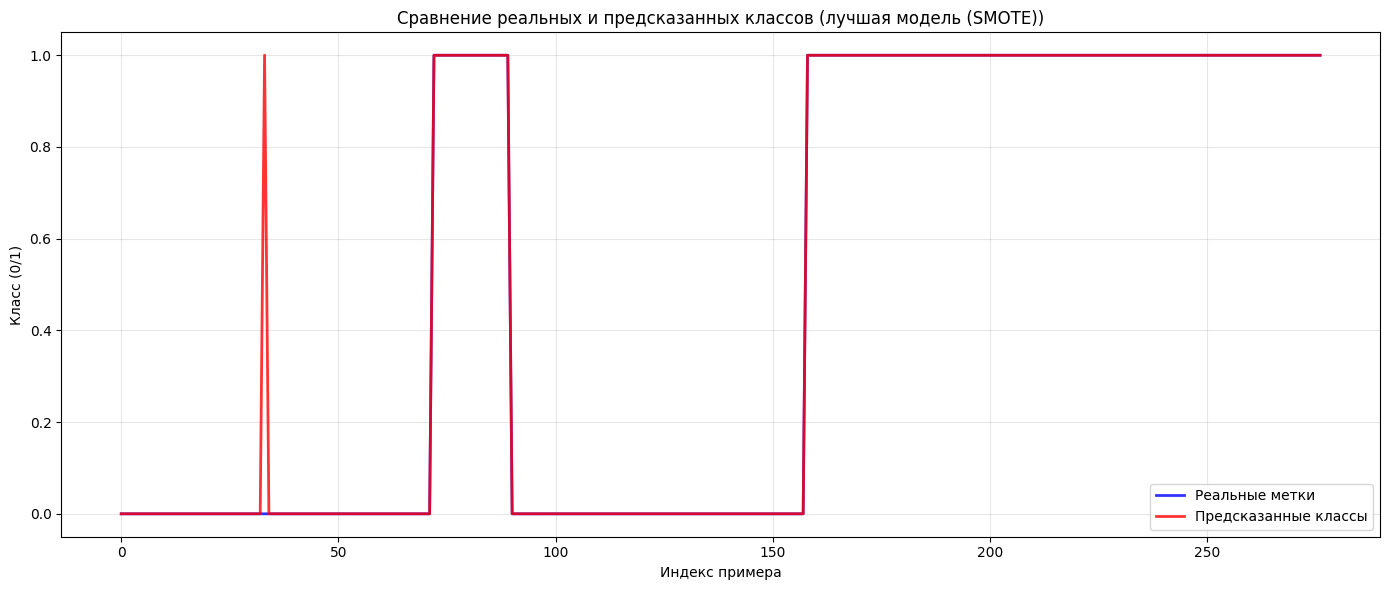

In [82]:
mlp = MLPClassifier(**best_params)
                
# Кросс-валидация для Accuracy
scores_acc = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv_folds, scoring='accuracy')
mean_acc = scores_acc.mean()
std_acc  = scores_acc.std()

# Кросс-валидация для F1-score
scores_f1 = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv_folds, scoring='f1')
mean_f1 = scores_f1.mean()
std_f1  = scores_f1.std()

# Сохраняем в список
results.append({
    'hidden_layer_sizes': str(hls),
    'activation': act,
    'solver': solv,
    'max_iter': max_it,
    'cv_mean_accuracy': mean_acc,
    'cv_std_accuracy': std_acc,
    'cv_mean_f1': mean_f1,
    'cv_std_f1': std_f1
})

df_results_adasyn = pd.DataFrame(results)

mlp.fit(X_adasyn, Y_adasyn)

plot_predictions(mlp, X_adasyn, Y_adasyn, 
                 title_suffix='лучшая модель (SMOTE)', 
                 save_path='best_model_predictions.png')


In [83]:
V1_C = pd.read_excel(config['data']['dataset_test_xlsx'])
display(V1_C.head(), V1_C.info(), V1_C.describe())

dt = 0.01
# Метод Эйлера
V1_alpha = np.zeros(len(V1_C))
for i in range(1, len(V1_C)):
    V1_alpha[i] = V1_alpha[i-1] + V1_C['gz'].values[i-1] * dt

V2_C, V3_C = compute_V2_V3(V1_C, V1_alpha, config)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      58 non-null     float64
 1   I2      58 non-null     float64
 2   I3      58 non-null     float64
 3   gx      58 non-null     float64
 4   gy      58 non-null     float64
 5   gz      58 non-null     float64
 6   ax      58 non-null     float64
 7   ay      58 non-null     float64
 8   az      58 non-null     float64
 9   V1real  58 non-null     float64
 10  V2real  58 non-null     float64
 11  V3real  58 non-null     float64
 12  N1      58 non-null     int64  
 13  N2      58 non-null     int64  
 14  N3      58 non-null     int64  
 15  Type    58 non-null     int64  
dtypes: float64(12), int64(4)
memory usage: 7.4 KB


,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
0,1.143286,0.016591,1.073907,0.343529,-0.032941,0.185294,0.018899,-0.003246,0.004323,-254.117647,0.000000,257.294118,-5081,-2,5062,1
1,0.499246,1.135747,0.481146,0.654118,0.263529,-1.826471,0.009004,-0.015884,-0.007669,162.000000,-308.117647,154.058824,2952,-5933,2991,1
2,0.351433,0.874811,0.942685,0.845882,0.114118,-3.032941,0.016070,-0.034309,-0.008215,-111.176471,-327.176471,462.176471,-2065,-6018,8444,1
3,0.333333,0.459566,0.258382,0.533077,-1.130769,16.233077,-0.008263,0.007343,0.021297,157.846154,162.000000,170.307692,3503,3338,3533,1
4,0.347008,0.353846,0.336752,0.093333,-1.026667,34.422667,-0.003776,-0.000049,0.003906,360.000000,352.800000,349.200000,5917,5931,5939,1


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503329,0.507012,0.530982,0.741187,-1.009176,22.819712,0.001161,-0.003513,-0.003626,176.737116,106.604473,352.529506,2984.465517,1652.103448,6109.741379,3.034483
std,0.328960,0.413925,0.324213,1.578123,2.024289,29.629883,0.015855,0.027644,0.019589,322.519851,371.325096,214.277036,5591.393563,6557.807800,3638.243964,1.426141
min,0.057315,0.000000,0.063348,-1.239375,-5.865625,-3.508824,-0.062402,-0.132782,-0.053271,-291.600000,-358.200000,-3.176471,-5807.000000,-8754.000000,-80.000000,1.000000
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-1925.000000,-4991.750000,3044.000000,2.000000
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,2708.500000,933.500000,5356.500000,3.000000
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,5812.750000,5801.750000,8003.750000,4.000000
max,1.274510,1.523378,1.162393,8.370000,2.211333,88.294667,0.050659,0.089615,0.087982,769.500000,772.200000,783.000000,14384.000000,14083.000000,14168.000000,5.000000


In [84]:
V3_C

,Tx,Ty,Tφ,Tz
0,9.226292,-1.831357,-14.650860,-8.012189
1,16.569436,11.467625,-16.357236,35.270291
2,17.712676,17.170432,-26.885145,32.087918
3,-6.002289,-0.391387,149.198143,46.323688
4,51.045007,-2.197545,327.523142,99.525247
5,2.662126,-8.673908,590.768634,184.140547
6,20.310336,31.740600,-16.174057,-10.146226
7,42.703817,62.563897,-17.971224,1.060801
8,91.736395,51.718592,-22.631657,-17.305534
9,-2.690158,-4.094441,233.528809,86.389274


In [85]:
V13_C = pd.concat([V1_C, V3_C], axis=1)
display(V13_C)

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type,Tx,Ty,Tφ,Tz
0,1.143286,0.016591,1.073907,0.343529,-0.032941,0.185294,0.018899,-0.003246,0.004323,-254.117647,0.000000,257.294118,-5081,-2,5062,1,9.226292,-1.831357,-14.650860,-8.012189
1,0.499246,1.135747,0.481146,0.654118,0.263529,-1.826471,0.009004,-0.015884,-0.007669,162.000000,-308.117647,154.058824,2952,-5933,2991,1,16.569436,11.467625,-16.357236,35.270291
2,0.351433,0.874811,0.942685,0.845882,0.114118,-3.032941,0.016070,-0.034309,-0.008215,-111.176471,-327.176471,462.176471,-2065,-6018,8444,1,17.712676,17.170432,-26.885145,32.087918
3,0.333333,0.459566,0.258382,0.533077,-1.130769,16.233077,-0.008263,0.007343,0.021297,157.846154,162.000000,170.307692,3503,3338,3533,1,-6.002289,-0.391387,149.198143,46.323688
4,0.347008,0.353846,0.336752,0.093333,-1.026667,34.422667,-0.003776,-0.000049,0.003906,360.000000,352.800000,349.200000,5917,5931,5939,1,51.045007,-2.197545,327.523142,99.525247
5,0.350961,0.451923,0.437500,-0.688750,-5.436250,76.135000,0.009110,0.022644,0.087982,759.375000,762.750000,767.812500,13176,13081,13128,1,2.662126,-8.673908,590.768634,184.140547
6,0.505983,0.003419,0.288889,0.724000,0.322000,0.722667,-0.001660,0.006966,0.002360,-291.600000,1.800000,300.600000,-4703,6,4877,2,20.310336,31.740600,-16.174057,-10.146226
7,0.224359,0.278846,0.174679,0.560625,0.382500,0.042500,-0.009125,-0.019577,0.008163,168.750000,-356.062500,180.562500,3007,-6222,3059,2,42.703817,62.563897,-17.971224,1.060801
8,0.225641,0.283760,0.280342,0.378667,0.157333,1.321333,0.008350,0.009814,0.001465,-113.400000,-354.600000,484.200000,-2035,-6223,8546,2,91.736395,51.718592,-22.631657,-17.305534
9,0.282051,0.331624,0.099145,0.541333,-0.878667,20.526667,0.002083,-0.017399,-0.005501,167.400000,165.600000,187.200000,2732,2726,2953,2,-2.690158,-4.094441,233.528809,86.389274


In [86]:
feature_cols_C = [col for col in V13_C.columns if col not in target_col]

dataC_x = np.array(V13_C.drop(target_col, axis=1))
dataC_y = np.array(V13_C[target_col]).ravel()

dataC_y = np.where(dataC_y == type_space, 1, 0)

scaler = MinMaxScaler()
dataC_x_scaled = scaler.fit_transform(dataC_x)

In [89]:
X_C_adasyn, Y_C_adasyn = adasyn.fit_resample(dataC_x_scaled, dataC_y)

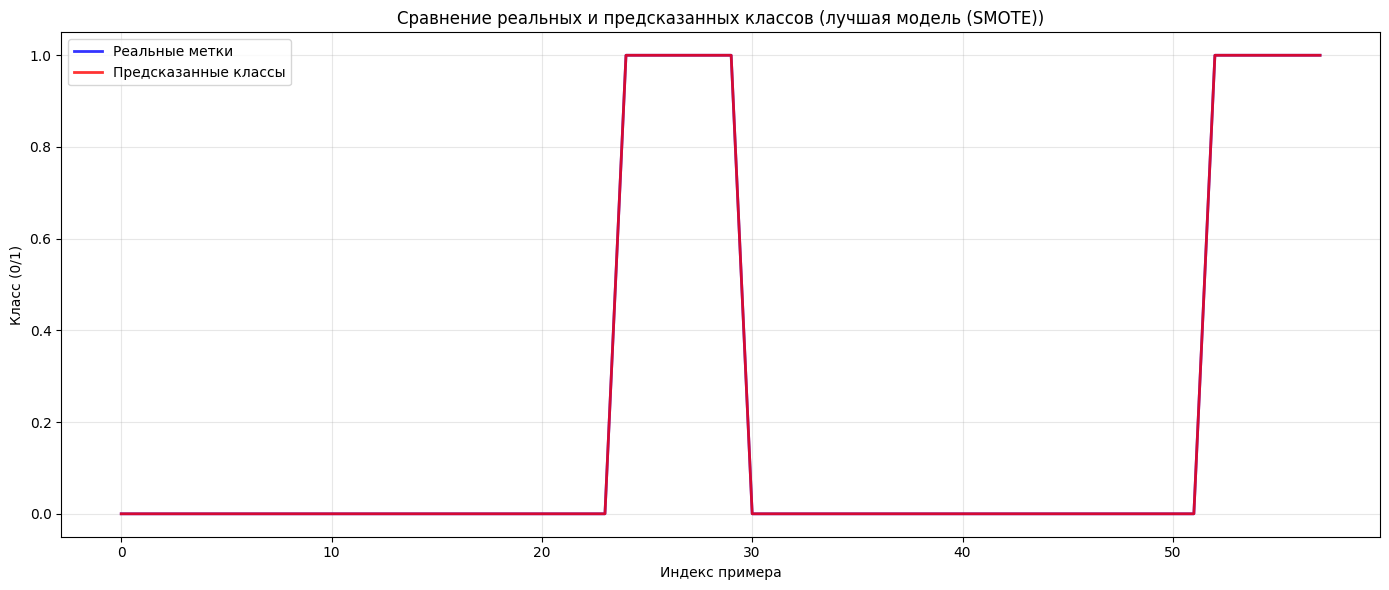

In [90]:
mlp.fit(dataC_x_scaled, dataC_y)

plot_predictions(mlp, dataC_x_scaled, dataC_y, 
                 title_suffix='лучшая модель (SMOTE)', 
                 save_path='best_model_predictions_C.png')

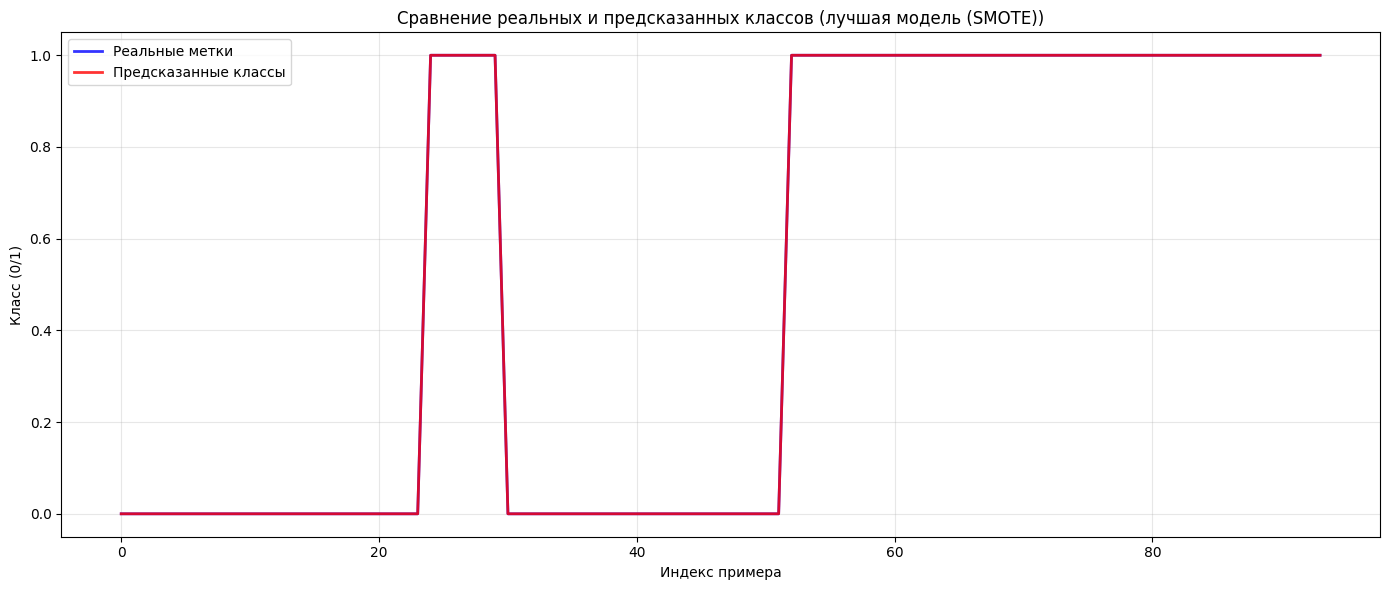

In [91]:
mlp.fit(X_C_adasyn, Y_C_adasyn)

plot_predictions(mlp, X_C_adasyn, Y_C_adasyn, 
                 title_suffix='лучшая модель (SMOTE)', 
                 save_path='best_model_predictions_C.png')